## Susceptibility

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["font.size"] = 16

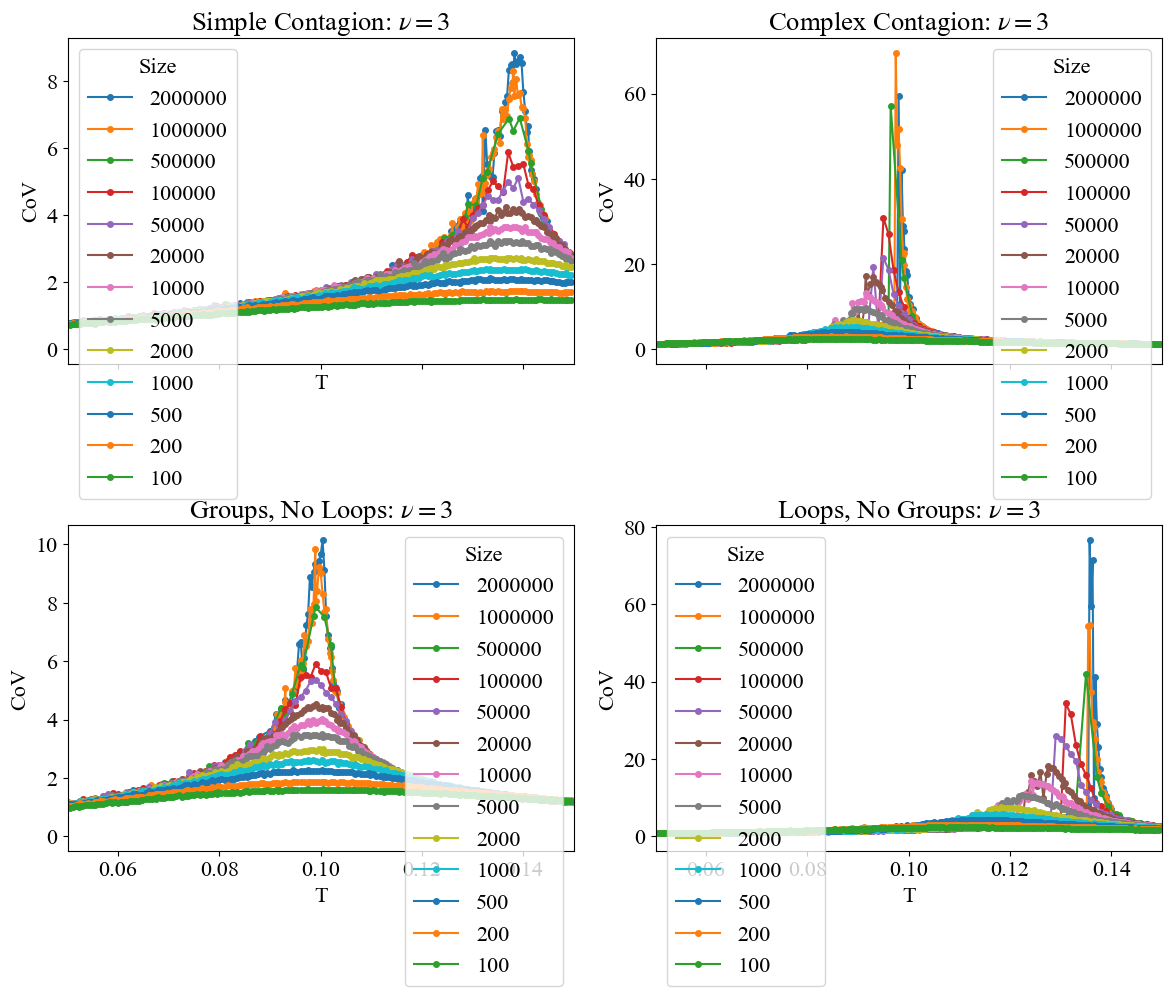

In [2]:
#sizes = ["1000000","500000"]
sizes = ["2000000", "1000000","500000", "100000","50000", "20000", "10000", "5000", "2000", "1000", "500", "200", "100"]
models = ["sc", "cc", "groupsnoloops", "loopsnogroups"]
#models = ["cc", "loopsnogroups", "groupsnoloops"]
nu = 3

data = {}
dfs = {}

for model in models:
    data[model] = {}
    dfs[model] = {}

    for s in sizes:
        path = f"data/logs_{s}/{model}_nu_{nu}_sims.txt"
        arr = np.loadtxt(path)
        data[model][s] = arr

        df = pd.DataFrame(arr, columns=["T", "S"])

        N = int(s)
        threshold = 0.00 * N

        # all T values (before filtering)
        all_T = np.sort(df["T"].unique())

        # filter
        df_filtered = df[df["S"] >= threshold]

        # df_clean = df_filtered.dropna()

        # group filtered data
        df_grouped = df_filtered.groupby("T").agg(
            n_obs=("S", "size"),
            S_mean=("S", "mean"),
            S_std=("S", "std"),
            S_q05=("S", lambda x: x.quantile(0.05)),
            S_q95=("S", lambda x: x.quantile(0.95))
        )

        # df_grouped = df_grouped[df_grouped["n_obs"] == 20000]

        # reindex to all T values
        df_grouped = df_grouped.reindex(all_T)

        # fill missing cases (no rows above threshold)
        df_grouped["S_mean"] = df_grouped["S_mean"]#.fillna(1.0)
        df_grouped["S_std"] = df_grouped["S_std"]#.fillna(0.0)

        # compute CoV
        df_grouped["S_cov"] = df_grouped["S_std"] / df_grouped["S_mean"]

        # ✅ new: fraction of system size
        df_grouped["S_mean_frac"] = df_grouped["S_mean"] / N

        # restore T as column
        df_grouped = df_grouped.reset_index()

        dfs[model][s] = df_grouped

# plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=False)
axes = axes.flatten()

titles = {
    "sc": "Simple Contagion",
    "cc": "Complex Contagion",
    "loopsnogroups": "Loops, No Groups",
    "groupsnoloops": "Groups, No Loops",
}

for ax, model in zip(axes, models):
    for s in dfs[model]:#sorted(dfs[model], key=int, reverse=True):
        df = dfs[model][s][dfs[model][s]["n_obs"]>=5000]
        ax.plot(df["T"], df["S_cov"], marker="o", label=s, markersize=4)

    ax.set_title(f"{titles[model]}: $\\nu = {nu}$")
    ax.set_xlabel("T")
    ax.set_xlim(0.05, 0.15)
    ax.set_ylabel("CoV")
    ax.legend(title="Size")

plt.tight_layout()
plt.show()

In [3]:
dfs["sc"]["2000000"]#[dfs["sc"]["2000000"]["n_obs"]==20000]
print(dfs["sc"]["2000000"])

            T  n_obs        S_mean         S_std  S_q05      S_q95     S_cov  \
0    0.000000  20000      1.000000      0.000000    1.0       1.00  0.000000   
1    0.002143  15000      1.014400      0.121355    1.0       1.00  0.119632   
2    0.003000   5000      1.019800      0.150374    1.0       1.00  0.147455   
3    0.004286  15000      1.031133      0.184480    1.0       1.00  0.178910   
4    0.006000   5000      1.038000      0.203382    1.0       1.00  0.195936   
..        ...    ...           ...           ...    ...        ...       ...   
164  0.144643  10000   8762.092500  33578.419053    1.0  131158.75  3.832237   
165  0.145714  15000  12719.767867  43342.305032    1.0  157882.65  3.407476   
166  0.147000   5000  16731.329200  53271.374204    1.0  184933.95  3.183930   
167  0.147857  15000  20438.387600  61289.182334    1.0  204238.25  2.998729   
168  0.150000  15000  30565.601867  81290.693331    1.0  248186.10  2.659548   

      S_mean_frac  
0    5.000000e-07  

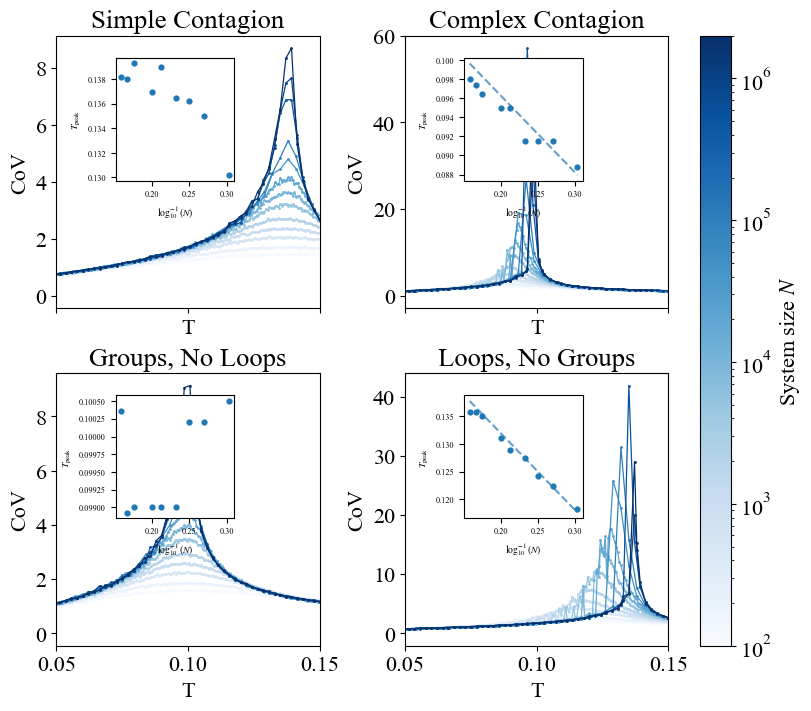

In [4]:
sizes = ["2000000", "1000000","500000", "100000","50000", "20000", "10000", "5000", "2000", "1000", "500", "200", "100"]
# convert sizes to integers
size_vals = np.array([int(s) for s in sizes])

sizes_short = [
    "2000000", "1000000", "500000",
    "100000", "50000", "20000",
    "10000", "5000", "2000"
]

# colormap
cmap = plt.cm.Blues

# logarithmic normalization
norm = mpl.colors.LogNorm(
    vmin=size_vals.min(),
    vmax=size_vals.max()
)

# plot
fig, axes = plt.subplots(
    2, 2,
    figsize=(8, 7),
    sharex=True,
    sharey=False,
    constrained_layout=True
)

axes = axes.flatten()

titles = {
    "sc": "Simple Contagion",
    "cc": "Complex Contagion",
    "loopsnogroups": "Loops, No Groups",
    "groupsnoloops": "Groups, No Loops",
}

for ax, model in zip(axes, models):

    for s in sorted(dfs[model], key=int):

        df = dfs[model][s][dfs[model][s]["n_obs"]>=15000]

        # color based on system size
        color = cmap(norm(int(s)))

        ax.plot(
            df["T"],
            df["S_cov"],
            marker="o",
            markersize=1,
            linewidth=0.9,
            color=color
        )

    ax.set_title(f"{titles[model]}")
    ax.set_xlabel("T")
    ax.set_xlim(0.05, 0.15)
    ax.set_ylabel("CoV")

    # =========================
    # INSET for this model
    # =========================

    # axins = inset_axes(
    #     ax,
    #     width="45%",
    #     height="45%",
    #     loc="upper center",
    #     bbox_to_anchor=(-0.05, 0, 1, 1),
    #     bbox_transform=ax.transAxes,
    #     borderpad=1
    # )
    if model == "sc":
        axins = inset_axes(
        ax,
        width="45%",
        height="45%",
        loc="upper center",
        bbox_to_anchor=(-0.05, 0, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=1
    )
    elif model == "cc":
        axins = inset_axes(
        ax,
        width="45%",
        height="45%",
        loc="upper center",
        bbox_to_anchor=(-0.05, 0, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=1
    )
    elif model == "loopsnogroups":
        axins = inset_axes(
        ax,
        width="45%",
        height="45%",
        loc="upper center",
        bbox_to_anchor=(-0.05, 0, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=1
    )
    elif model == "cc":
        axins = inset_axes(
        ax,
        width="45%",
        height="45%",
        loc="upper right",
        bbox_to_anchor=(0, 0, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=1
    )
    else:
        axins = inset_axes(
        ax,
        width="45%",
        height="45%",
        loc="upper center",
        bbox_to_anchor=(-0.05, 0, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=1
    )

    T_at_peak = []

    for s in sizes_short:
        df = dfs[model][s]
        T_at_peak.append(df.loc[df["S_cov"].idxmax(), "T"])

    sizes_int = np.array(sizes_short).astype(int)
    xvals = 1 / np.log10(sizes_int)

    if model == "loopsnogroups":
        pred_T = -0.14 / np.log10(sizes_int) + 0.16
        axins.plot(
        xvals,
        pred_T,
        linestyle="--",
        alpha=0.7
    )
    elif model == "cc":
        pred_T = -0.081 / np.log10(sizes_int) + 0.1125
        axins.plot(
        xvals,
        pred_T,
        linestyle="--",
        alpha=0.7
    )

    axins.scatter(
        xvals,
        T_at_peak,
        s=12
    )

    axins.set_xlabel(r"$\log_{10}^{-1}(N)$", fontsize=7)
    axins.set_ylabel(r"$T_{\mathrm{peak}}$", fontsize=7)
    axins.tick_params(axis="both", labelsize=6)

# shared colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    pad=0.02
)

cbar.set_label("System size $N$")

# plt.tight_layout()
plt.show()

fig.savefig("/Users/leah/Documents/Critical_Mass_BP/Crit_Mass_BP_CC/plots/susceptibility.pdf")

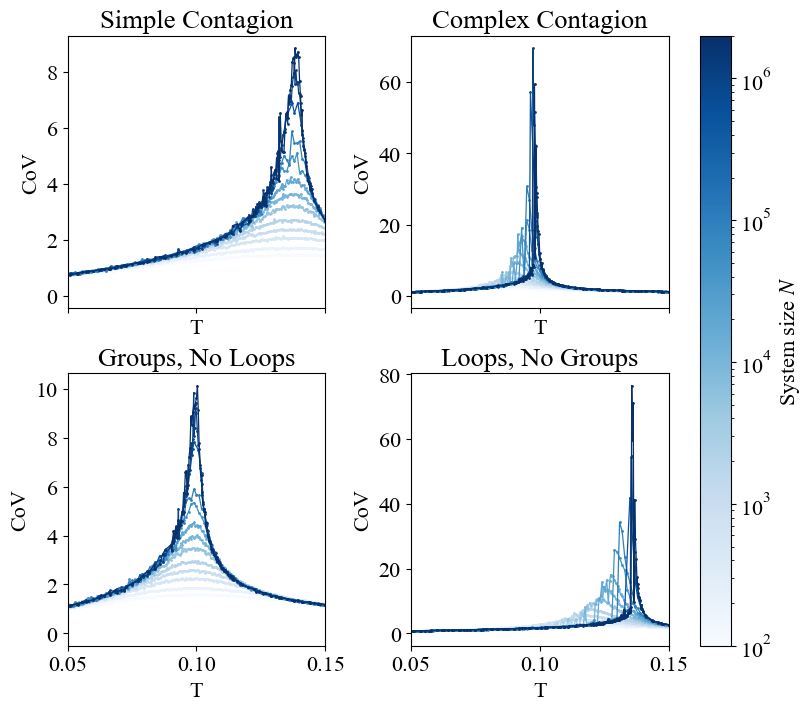

In [5]:
sizes = ["2000000", "1000000","500000", "100000","50000", "20000", "10000", "5000", "2000", "1000", "500", "200", "100"]
# convert sizes to integers
size_vals = np.array([int(s) for s in sizes])

sizes_short = [
    "2000000", "1000000", "500000",
    "100000", "50000", "20000",
    "10000", "5000", "2000"
]

# colormap
cmap = plt.cm.Blues

# logarithmic normalization
norm = mpl.colors.LogNorm(
    vmin=size_vals.min(),
    vmax=size_vals.max()
)

# plot
fig, axes = plt.subplots(
    2, 2,
    figsize=(8, 7),
    sharex=True,
    sharey=False,
    constrained_layout=True
)

axes = axes.flatten()

titles = {
    "sc": "Simple Contagion",
    "cc": "Complex Contagion",
    "loopsnogroups": "Loops, No Groups",
    "groupsnoloops": "Groups, No Loops",
}

for ax, model in zip(axes, models):

    for s in sorted(dfs[model], key=int):

        df = dfs[model][s][dfs[model][s]["n_obs"]>=5000]

        # color based on system size
        color = cmap(norm(int(s)))

        ax.plot(
            df["T"],
            df["S_cov"],
            marker="o",
            markersize=1,
            linewidth=0.9,
            color=color
        )

    ax.set_title(f"{titles[model]}")
    ax.set_xlabel("T")
    ax.set_xlim(0.05, 0.15)
    ax.set_ylabel("CoV")

    # =========================
    # INSET for this model
    # =========================

    # axins = inset_axes(
    #     ax,
    #     width="45%",
    #     height="45%",
    #     loc="upper center",
    #     bbox_to_anchor=(-0.05, 0, 1, 1),
    #     bbox_transform=ax.transAxes,
    #     borderpad=1
    # )
    # if model == "sc":
    #     axins = inset_axes(
    #     ax,
    #     width="45%",
    #     height="45%",
    #     loc="upper center",
    #     bbox_to_anchor=(-0.05, 0, 1, 1),
    #     bbox_transform=ax.transAxes,
    #     borderpad=1
    # )
    # elif model == "cc":
    #     axins = inset_axes(
    #     ax,
    #     width="45%",
    #     height="45%",
    #     loc="upper center",
    #     bbox_to_anchor=(-0.05, 0, 1, 1),
    #     bbox_transform=ax.transAxes,
    #     borderpad=1
    # )
    # elif model == "loopsnogroups":
    #     axins = inset_axes(
    #     ax,
    #     width="45%",
    #     height="45%",
    #     loc="upper center",
    #     bbox_to_anchor=(-0.05, 0, 1, 1),
    #     bbox_transform=ax.transAxes,
    #     borderpad=1
    # )
    # elif model == "cc":
    #     axins = inset_axes(
    #     ax,
    #     width="45%",
    #     height="45%",
    #     loc="upper right",
    #     bbox_to_anchor=(0, 0, 1, 1),
    #     bbox_transform=ax.transAxes,
    #     borderpad=1
    # )
    # else:
    #     axins = inset_axes(
    #     ax,
    #     width="45%",
    #     height="45%",
    #     loc="upper center",
    #     bbox_to_anchor=(-0.05, 0, 1, 1),
    #     bbox_transform=ax.transAxes,
    #     borderpad=1
    # )

    T_at_peak = []

    for s in sizes_short:
        df = dfs[model][s]
        T_at_peak.append(df.loc[df["S_cov"].idxmax(), "T"])

    sizes_int = np.array(sizes_short).astype(int)
    xvals = 1 / np.log10(sizes_int)

    if model == "loopsnogroups":
        pred_T = -0.14 / np.log10(sizes_int) + 0.16
        axins.plot(
        xvals,
        pred_T,
        linestyle="--",
        alpha=0.7
    )
    elif model == "cc":
        pred_T = -0.081 / np.log10(sizes_int) + 0.1125
        axins.plot(
        xvals,
        pred_T,
        linestyle="--",
        alpha=0.7
    )

    axins.scatter(
        xvals,
        T_at_peak,
        s=12
    )

    axins.set_xlabel(r"$\log_{10}^{-1}(N)$", fontsize=7)
    axins.set_ylabel(r"$T_{\mathrm{peak}}$", fontsize=7)
    axins.tick_params(axis="both", labelsize=6)

# shared colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    pad=0.02
)

cbar.set_label("System size $N$")

# plt.tight_layout()
plt.show()

fig.savefig("/Users/leah/Documents/Critical_Mass_BP/Crit_Mass_BP_CC/plots/susceptibility_no_inset.pdf")

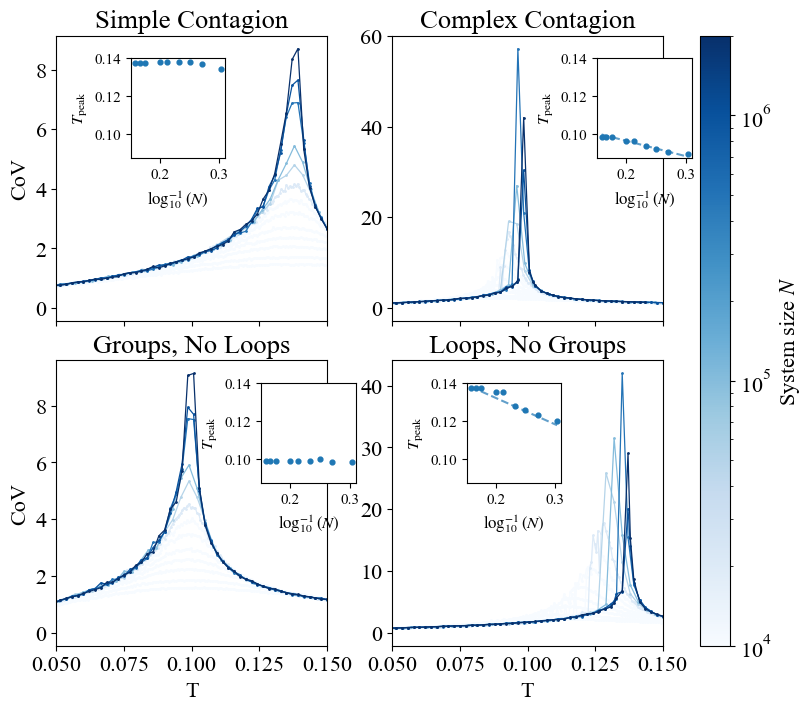

In [7]:
sizes = ["2000000", "1000000", "500000", "100000", "50000", "20000", "10000"]
size_vals = np.array([int(s) for s in sizes])

sizes_short = [
    "2000000", "1000000", "500000",
    "100000", "50000", "20000",
     "10000", "5000", "2000"
]

cmap = plt.cm.Blues
norm = mpl.colors.LogNorm(vmin=size_vals.min(), vmax=size_vals.max())

fig, axes = plt.subplots(
    2, 2,
    figsize=(8, 7),
    sharex=True,
    sharey=False,
    constrained_layout=True
)

axes = axes.flatten()

titles = {
    "sc": "Simple Contagion",
    "cc": "Complex Contagion",
    "loopsnogroups": "Loops, No Groups",
    "groupsnoloops": "Groups, No Loops",
}

inset_settings = {
    "sc": {
        "loc": "upper center",
        "bbox_to_anchor": (-0.05, 0, 1, 1),
        "width": "35%",
        "height": "35%",
    },
    "cc": {
        "loc": "upper right",
        "bbox_to_anchor": (0.19, 0, 1, 1),
        "width": "35%",
        "height": "35%",
    },
    "loopsnogroups": {
        "loc": "upper center",
        "bbox_to_anchor": (-0.05, 0, 1, 1),
        "width": "35%",
        "height": "35%",
    },
    "groupsnoloops": {
        "loc": "upper right",
        "bbox_to_anchor": (0.19, 0, 1, 1),
        "width": "35%",
        "height": "35%",
    },
}


def peak_T(df):
    # T at the susceptibility peak: median T of the 3 highest-CoV points,
    # restricted to T values that are actually drawn (n_obs >= 15000)
    df = df[df["n_obs"] >= 15000]
    top3 = df.nlargest(5, "S_cov")
    return top3["T"].median()


all_t_peaks = []

for model in models:
    for s in sizes_short:
        if s in dfs[model]:
            df = dfs[model][s]
            all_t_peaks.append(peak_T(df))

ymin = min(all_t_peaks)
ymax = max(all_t_peaks)

padding = 0.002

ymin -= padding
ymax += padding

for ax, model in zip(axes, models):

    # Main susceptibility curves
    for s in sorted(dfs[model], key=int):

        df = dfs[model][s][dfs[model][s]["n_obs"]>=15000]
        color = cmap(norm(int(s)))

        ax.plot(
            df["T"],
            df["S_cov"],
            marker="o",
            markersize=1,
            linewidth=0.9,
            color=color
        )

    ax.set_title(titles[model])
    # ax.set_xlabel("T")
    ax.set_xlim(0.05, 0.15)
    # ax.set_ylabel("CoV")
    # left column only
    if ax in [axes[0], axes[2]]:
        ax.set_ylabel("CoV")
    else:
        ax.set_ylabel("")

    # bottom row only
    if ax in [axes[2], axes[3]]:
        ax.set_xlabel("T")
    else:
        ax.set_xlabel("")

    # =========================
    # INSET for this model
    # =========================

    settings = inset_settings[model]

    axins = inset_axes(
        ax,
        width=settings["width"],
        height=settings["height"],
        loc=settings["loc"],
        bbox_to_anchor=settings["bbox_to_anchor"],
        bbox_transform=ax.transAxes,
        borderpad=1
    )

    available_sizes = [s for s in sizes_short if s in dfs[model]]

    T_at_peak = []

    for s in available_sizes:
        df = dfs[model][s]
        T_at_peak.append(peak_T(df))

    sizes_int = np.array(available_sizes).astype(int)
    xvals = 1 / np.log10(sizes_int)

    # Optional prediction lines for selected models
    if model == "loopsnogroups":
        pred_T = -0.14 / np.log10(sizes_int) + 0.16
        axins.plot(
            xvals,
            pred_T,
            linestyle="--",
            alpha=0.7
        )

    elif model == "cc":
        pred_T = -0.081 / np.log10(sizes_int) + 0.1125
        axins.plot(
            xvals,
            pred_T,
            linestyle="--",
            alpha=0.7
        )

    axins.scatter(
        xvals,
        T_at_peak,
        s=12
    )
    
    axins.set_ylim(ymin, ymax)
    axins.set_xlabel(r"$\log_{10}^{-1}(N)$", fontsize=12)
    axins.set_ylabel(r"$T_{\mathrm{peak}}$", fontsize=12)
    axins.tick_params(axis="both", labelsize=11)

# Shared colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    pad=0.02
)

cbar.set_label("System size $N$")

plt.show()

fig.savefig(
    "susceptibility.pdf"
)

In [7]:
#sizes = ["1000000","500000"]
sizes = ["2000000", "1000000","500000", "100000","50000", "20000", "10000", "5000", "2000", "1000", "500", "200", "100"]
models = ["sc", "cc", "loopsnogroups", "groupsnoloops"]
#models = ["cc", "loopsnogroups", "groupsnoloops"]
nu = 3

n_boot = 1000
rng = np.random.default_rng(12345)

def bootstrap_cov(x, n_boot=1000):
    x = np.asarray(x.dropna())

    if len(x) < 2 or np.mean(x) == 0:
        return pd.Series({
            "S_mean": np.mean(x) if len(x) > 0 else np.nan,
            "S_std": np.nan,
            "S_cov": np.nan,
            "S_cov_q05": np.nan,
            "S_cov_q95": np.nan,
        })

    S_mean = x.mean()
    S_std = x.std(ddof=1)
    S_cov = S_std / S_mean

    boot_cov = np.empty(n_boot)

    for i in range(n_boot):
        sample = rng.choice(x, size=len(x), replace=True)
        sample_mean = sample.mean()

        if sample_mean == 0:
            boot_cov[i] = np.nan
        else:
            boot_cov[i] = sample.std(ddof=1) / sample_mean

    return pd.Series({
        "S_mean": S_mean,
        "S_std": S_std,
        "S_cov": S_cov,
        "S_cov_q05": np.nanquantile(boot_cov, 0.05),
        "S_cov_q95": np.nanquantile(boot_cov, 0.95),
    })


data = {}
dfs = {}

for model in models:
    data[model] = {}
    dfs[model] = {}

    for s in sizes:
        path = f"logs_Apr27/logs_{s}/{model}_nu_{nu}_sims.txt"
        arr = np.loadtxt(path)
        data[model][s] = arr

        df = pd.DataFrame(arr, columns=["T", "S"])

        N = int(s)
        threshold = 0.00 * N

        # all T values before filtering
        all_T = np.sort(df["T"].unique())

        # filter
        df_filtered = df[df["S"] >= threshold]

        # bootstrap CoV uncertainty for each T
        df_grouped = (
            df_filtered
            .groupby("T")["S"]
            .apply(lambda x: bootstrap_cov(x, n_boot=n_boot))
            .reset_index()
        )

        # after groupby/apply, pandas gives columns: T, level_1, S
        df_grouped = df_grouped.pivot(
            index="T",
            columns="level_1",
            values="S"
        )

        # reindex to all T values
        df_grouped = df_grouped.reindex(all_T)

        # fraction of system size
        df_grouped["S_mean_frac"] = df_grouped["S_mean"] / N

        # restore T as column
        df_grouped = df_grouped.reset_index()

        dfs[model][s] = df_grouped


# plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=False)
axes = axes.flatten()

titles = {
    "sc": "Simple Contagion",
    "cc": "Complex Contagion",
    "loopsnogroups": "Loops, No Groups",
    "groupsnoloops": "Groups, No Loops",
}

for ax, model in zip(axes, models):
    for s in sorted(dfs[model], key=int, reverse=True):
        df = dfs[model][s]

        line, = ax.plot(
            df["T"],
            df["S_cov"],
            marker="o",
            label=s,
            markersize=4,
        )

        ax.fill_between(
            df["T"],
            df["S_cov_q05"],
            df["S_cov_q95"],
            alpha=0.2,
            color=line.get_color(),
        )

    ax.set_title(f"{titles[model]}: $\\nu = {nu}$")
    ax.set_xlabel("T")
    ax.set_xlim(0.05, 0.15)
    ax.set_ylabel("CoV")
    ax.legend(title="Size")

plt.tight_layout()
plt.show()

FileNotFoundError: logs_Apr27/logs_2000000/sc_nu_3_sims.txt not found.

[2000000 1000000  500000  100000   50000   20000   10000    5000    2000]


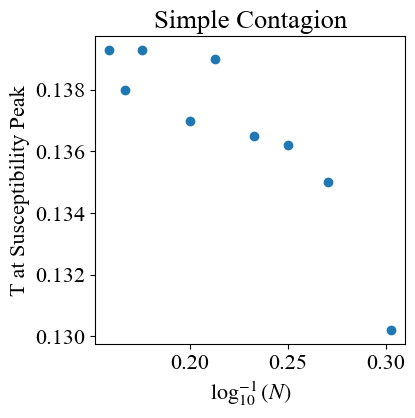

In [55]:
sizes_short = ["2000000", "1000000","500000", "100000","50000", "20000", "10000", "5000", "2000"]#, "1000", "500", "200", "100"]


T_at_peak = []
for s in sizes_short:
    df = dfs["sc"][s]
    T_at_peak.append(df.loc[df["S_cov"].idxmax(), "T"])

print(np.array(sizes_short).astype(int))
pred_T = -0.081/np.log10(np.array(sizes_short).astype(int)) + 0.1125

fig, ax = plt.subplots(figsize=(4, 4))
# ax.plot(1/np.log10(np.array(sizes_short).astype(int)), pred_T, linestyle = "--", alpha=0.7)
ax.scatter(1/np.log10(np.array(sizes_short).astype(int)), T_at_peak, marker="o")
ax.set_xlabel("$\\log_{10}^{-1}(N)$")
ax.set_ylabel("T at Susceptibility Peak")
ax.set_title("Simple Contagion")
plt.show()

Text(0.5, 1.0, 'Groups, no loops')

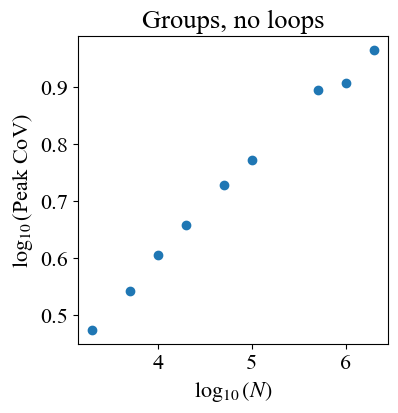

In [68]:
sizes_short = ["2000000", "1000000","500000", "100000","50000", "20000", "10000", "5000", "2000"]#, "1000", "500", "200", "100"]


peaks = []
for s in sizes_short:
    df = dfs["groupsnoloops"][s]
    peaks.append(df["S_cov"].max())

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(np.log10(np.array(sizes_short).astype(int)), np.log10(np.array(peaks)), marker="o")
ax.set_xlabel("$\\log_{10}(N)$")
ax.set_ylabel("$\\log_{10}$(Peak CoV)")
ax.set_title("Groups, no loops")

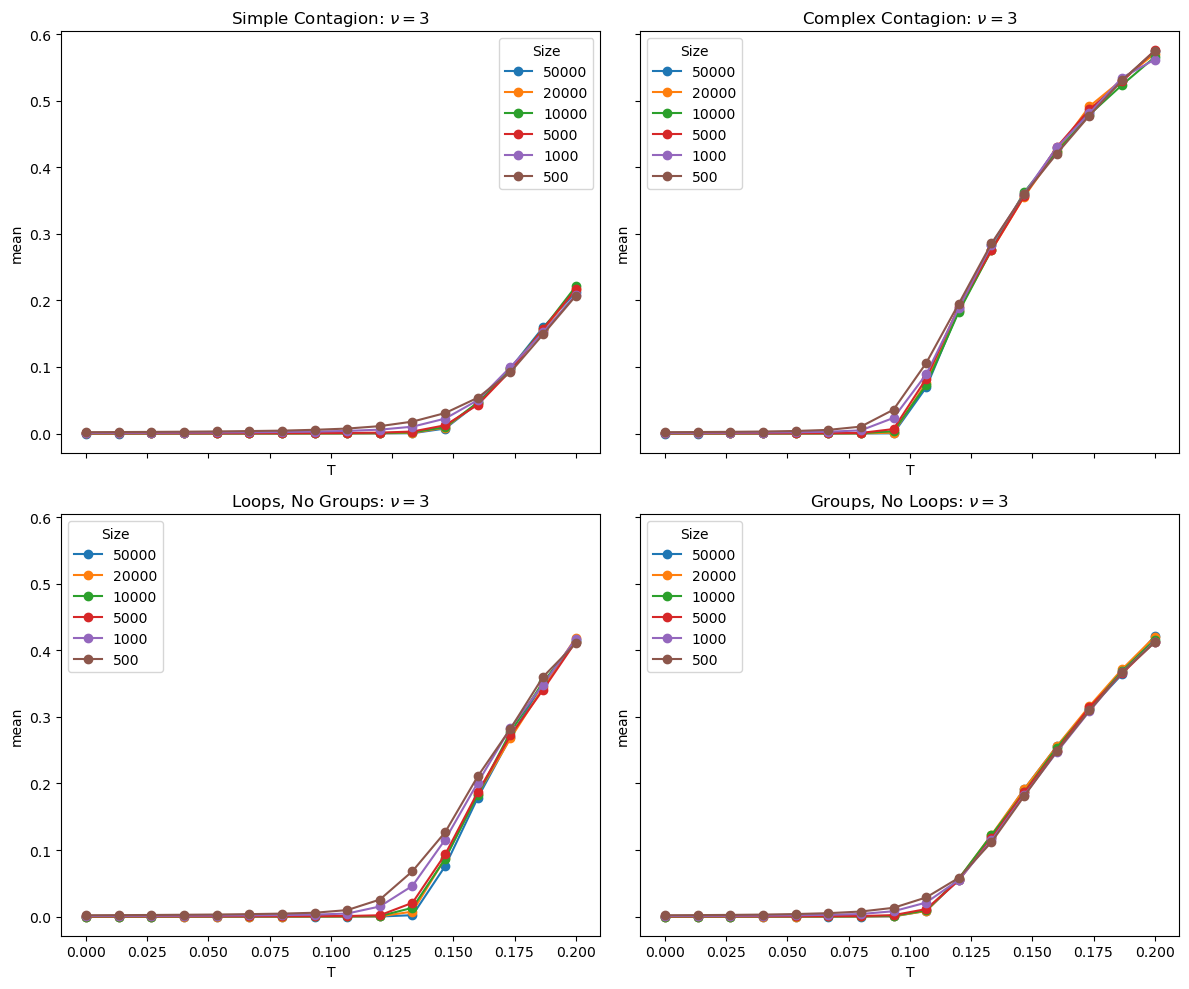

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()

titles = {
    "sc": "Simple Contagion",
    "cc": "Complex Contagion",
    "loopsnogroups": "Loops, No Groups",
    "groupsnoloops": "Groups, No Loops",
}

for ax, model in zip(axes, models):
    for s in sorted(dfs[model], key=int, reverse=True):
        df = dfs[model][s]
        ax.plot(df["T"], df["S_mean_frac"], marker="o", label=s)

    ax.set_title(f"{titles[model]}: $\\nu = {nu}$")
    ax.set_xlabel("T")
    ax.set_ylabel("mean")
    ax.legend(title="Size")

plt.tight_layout()
plt.show()

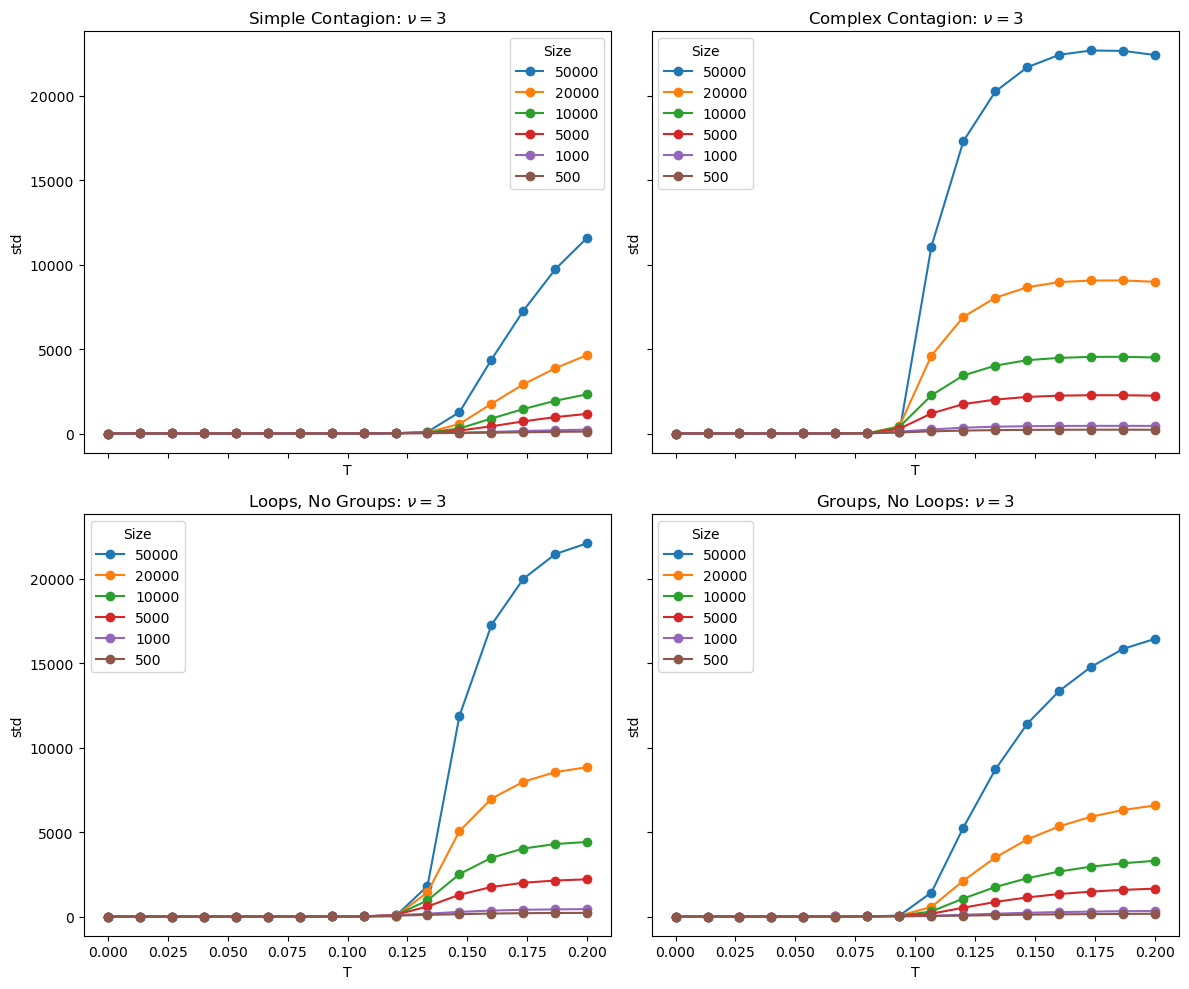

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()

titles = {
    "sc": "Simple Contagion",
    "cc": "Complex Contagion",
    "loopsnogroups": "Loops, No Groups",
    "groupsnoloops": "Groups, No Loops",
}

for ax, model in zip(axes, models):
    for s in sorted(dfs[model], key=int, reverse=True):
        df = dfs[model][s]
        ax.plot(df["T"], df["S_std"], marker="o", label=s)

    ax.set_title(f"{titles[model]}: $\\nu = {nu}$")
    ax.set_xlabel("T")
    ax.set_ylabel("std")
    ax.legend(title="Size")

plt.tight_layout()
plt.show()

In [ ]:
data["sc"]["2000000"]

array([[0.00000e+00, 1.00000e+00],
       [0.00000e+00, 1.00000e+00],
       [0.00000e+00, 1.00000e+00],
       ...,
       [1.50000e-01, 2.56128e+05],
       [1.50000e-01, 1.00000e+00],
       [1.50000e-01, 5.00000e+01]])